# <font color=red>Solutions for</font> Exercises 05 <font color=blue>Version 1.1 </font>

In [47]:
import numpy as np
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

## An Overview, and a Recollection
This Lab is packed with concepts that may all seem very disjointed and unrelated. However, you have seen them all in previous labs and exercises, albeit in a much less verbose form. In fact, you can think of the concepts here as the broader and more versatile applications of their previous versions, able to do things that would otherwise be very limited. The goal of these Exercises are to show you the differences between the previous versions and these newer ones, where and when to use each one, and how they can combine in particular applications.

### for/in
This is the main tool for repetitive actions. It was a heavy focus in Exercises 02, and used still in 03 and 04. This format you will likely have etched into your mind by now:

In [2]:
ExampleList = [1,2,3,4,5]
SquaredList = [x**2 for x in ExampleList] # This takes each term in ExampleList and applies an operation (and/or function/method) to it.
# In this case, the operation is squaring each term.
SquaredList

[1, 4, 9, 16, 25]

This is how that same thing would be expressed in the larger for/in format introduced in Lab 05.

In [3]:
ExampleList = [1,2,3,4,5]
SquaredList = []
# Instead of defining SquaredList as a modification of the terms in ExampleList,
# we will instead create a brand new list and add the modified terms to it
for x in ExampleList: # this MUST be something indexable (usually a list/array)
    SquaredList.append(x**2)
SquaredList

[1, 4, 9, 16, 25]

Now, the larger format takes up more space, but it allows you to do repetitive actions with terms that are NOT Lists or Arrays. Anything that has indexable terms can become the subject of a for/in loop now. This includes Strings and entire Tables!

In [4]:
word = ''
for x in 'bnn':
    word = word+x+'a'
word

'banana'

In [5]:
ExampleTable = Table().with_columns('Column1', [6,5,2,5,6], 'Column2', [2,6,4,8,9], 'Column3', [3,1,2,3,5], 'Column4', [6,5,7,8,1])
for x in ExampleTable: # Strangely, this will not give you the column arrays, but the column LABELS
    print(x)

Column1
Column2
Column3
Column4


### if/elif/else
This is the main tool for conditionals. You also say a heavily condensed version, paired with the for/in, in Exercises 02.

In [6]:
[x for x in ExampleList if x%2 == 1] # What this is doing is that it is only keeping the terms that have a remainder of 1

[1, 3, 5]

This is great for filtering, but it is also very limited in its usage because it automatically kicks out the terms that do not match the conditional.

For example, if you wanted a column in a Table that tells you if a given number is even or odd, you can't do it since the resltant list does not have the same number of terms as the columns. (Remember, you can only add lists/arrays as columns in a Table if they have the same length as the columns.)

In [7]:
ExampleTable

Column1,Column2,Column3,Column4
6,2,3,6
5,6,1,5
2,4,2,7
5,8,3,8
6,9,5,1


Thus, what we need is multiple paths, that will do one thing for odd and another thing for even. This is not possible for the list, but it is for the larger Lab 05 if/else format.

In [8]:
Parity = []

In [9]:
x = 4 # Try replacing this x value with whatever you want
if x%2 == 1: # it goes down this path if the conditional is True
    Parity.append('odd')
elif x%2 == 0: # if the first one is False, it will move here and check this.
    Parity.append('even')
else: # if both of the above are not met, it goes here.
    Parity.append('Not an Integer')
    

In [10]:
Parity

['even']

This was only for a singular case, but we can use it in combination with a for/in.

In [11]:
Column4 = ExampleTable.column(3)
ParityColumn4 = []
for x in Column4: # note the indenting here: the entire if/else is within the for loop.
    if x%2 == 1:
        ParityColumn4.append('odd')
    elif x%2 == 0:
        ParityColumn4.append('even')
    else:
        ParityColumn4.append('Not an Integer')
ParityColumn4

['even', 'odd', 'odd', 'even', 'odd']

Since it didn't kick out any terms, we can add it to the table!

In [12]:
ExampleTable = ExampleTable.with_column('Parity of Column 4', ParityColumn4) # this will give an error, since its length is now different from the table length
ExampleTable

Column1,Column2,Column3,Column4,Parity of Column 4
6,2,3,6,even
5,6,1,5,odd
2,4,2,7,odd
5,8,3,8,even
6,9,5,1,odd


You may have realized that the Parity was something that could not be distinguished through something like `Table.where(...)`. However, once the for/in loop happened, and the new column was created, you are now able to use the `Table.where(...)` to separate the evens and odds. 

## Variations and Applications
The for/in and if/elif/else are perhaps the most versatile parts of code, in that they allow you to repeat an operation many times and alter that operation depending on the exact input. 

The if/elif/else also has several nice quirks for particular instances.

``if [Conditional 1] or [Conditional 2] or [Conditional 3] (and so on):`` 

(this means that if ANY of the conditionals are satisfied, it will go down this path.)

``if [Conditional 1] and [Conditional 2] and [Conditional 3] (and so on):`` 

(this means ONLY if ALL of the conditionals are satisfied, it will go down this path.)

Although it's possible to use both `and` and `or` in the same line, you get into all sorts of logic-related complications. It's typically best to use separate if/elif lines for stuff like that.

`pass`

(if you don't want the kernel to do anything when it goes down a specific path, use this.)

### Tallying
A nice use of for/in is to count up the instances in which something happens. This was the subject of the earlier exercises in Lab 05, especially Problems 3 and 4. Effectively, you set a variable to 0 outside the loop (!) and for each instance of some conditional, you add some value to that variable. Given that there are examples in Lab 05, and *I don't want to do the labs for you*, that's all I'll tell you.

### Tracking
This is something that's very good for debugging. The main danger regarding for/in is that whatever operations that would occur only once instead get multiplied by however many loops there are (how many terms there are in the relevant list/array). This means that particularly long and/or tedious loops will take a long time, and it becomes harder to see whether your loop is entirely broken/malfunctioning or just chugging away at a massive task.

To make sure your code is working alright, it may help to insert a 'tracker'. Every so often, it will activate and show what loop the for/in operation is at.

In [13]:
for x in np.arange(10000): # humongous number of loops!
    # pretend there's some complicated stuff here.
    
    # this is the tracker bit:
    if x%1000 == 0: # every thousandth iteration, it will output an update
        print(x, 'loops done')
    else:
        pass # otherwise, it stays silent (you don't want to flood your output!)

0 loops done
1000 loops done
2000 loops done
3000 loops done
4000 loops done
5000 loops done
6000 loops done
7000 loops done
8000 loops done
9000 loops done


## Exercise 1: New Data Insights
As shown above, the for/in combined with the if/else allows you to distinguish data in certain ways that would otherwise be out of the bounds of analysis. This part will look at the GroundHog data tables, and try to ascertain new data that would be harder or more tedious to do than `Table.where(...)`.

In [14]:
hogwash_sum = Table.read_table('GroundHogData/summarizedGroundhogData_20210326.csv')
hogwash_sum = hogwash_sum.drop('GDD', 'cGDD', 'numObs', 'meanJulSpringDay', 'sdJulSpringDay', 'seJulSpringDay')
hogwash_sum

hogID,year,shadowPres,dateSample,julDay,earlyOrLate
BC,2018,yes,2018-04-11,101,late
BC,2019,no,2019-04-06,96,late
BECK,2006,yes,2006-02-15,46,early
BECK,2007,no,2007-03-14,73,late
BECK,2008,no,2008-03-17,77,late
BECK,2009,yes,2009-03-10,69,early
BECK,2010,no,2010-03-21,80,late
BECK,2011,no,2011-03-20,79,late
BECK,2012,no,2012-03-07,67,early
BECK,2013,no,2013-03-30,89,late


In [15]:
hogwash_temp = Table.read_table('GroundHogData/hogTemp_USA.csv')
hogwash_temp = hogwash_temp.drop('STATION', 'LATITUDE', 'LONGITUDE')
hogwash_temp

hogID,STATION NAME,elevation,dateSample,tempAverage,tempMax,tempMin
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-01,41,49.8,32.2
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-02,40.9,49.7,32.1
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-03,40.8,49.6,32.1
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-04,40.8,49.5,32
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-05,40.7,49.4,32
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-06,40.7,49.4,32
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-07,40.6,49.3,31.9
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-08,40.6,49.3,31.9
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-09,40.5,49.2,31.9
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-10,40.5,49.2,31.9


### Exercise 1.1:
As a quick review of earlier labs and exercises, create a new column for `hogwash_temp` that shows what state they are in. 

Hints: 
* Although it's possible to use a single line of code, it may be more legible to use a full-fledged loop. Refer to the examples above in that case.
* Where can you find the state? You can keep it in its initials form.
* How do you extract the state from that whole string mess? Look to Lab 02 and Exercises 02 for help. Keep in mind that the string will change dramatically from station to station. What parts are the same, that you can exploit? 

In [16]:
state = []
for x in hogwash_temp.column("STATION NAME"):
    target = x.split(' ')[-2]
    state.append(target)
    # i'm inserting a tracker here for fun.
    if len(state)%50000==0:
        print(len(state))
    else:
        pass

50000
100000
150000


In [17]:
hogwash_temp = hogwash_temp.with_column('state', state)
hogwash_temp

hogID,STATION NAME,elevation,dateSample,tempAverage,tempMax,tempMin,state
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-01,41,49.8,32.2,VA
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-02,40.9,49.7,32.1,VA
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-03,40.8,49.6,32.1,VA
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-04,40.8,49.5,32,VA
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-05,40.7,49.4,32,VA
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-06,40.7,49.4,32,VA
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-07,40.6,49.3,31.9,VA
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-08,40.6,49.3,31.9,VA
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-09,40.5,49.2,31.9,VA
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-10,40.5,49.2,31.9,VA


### Exercise 1.2:
Now comes the juicy bit. Do some outside researching to get the census regions and divisions of the US. Use your trusty for/in and if/else coding skillz to create two new columns for `hogwash_temp`, one for the region and another for the division. 

Hints:
* Keep your indentations in mind. A single mis-indented line has the capacity to break the entire thing.
* You don't want to do 50 separate if/else possibilities (that would be inhumane). Instead, use `or` (shown above). DON'T USE OR! There is a MUCH faster way and I promise you that you do not want to do any other method than that fastest way. Refer back to the list of conditionals!
* You need to create the empty lists for the region and division columns before *and outside* the for/in loop, and then append each result to them.

In [18]:
region = []
division = []
# There exists a method that is 1,000 times easier and more efficient,
# which involves puting state strings into lists and using the 'in' conditional
# This below is the Slower Way:

# honestly, this right here is abysmal levels of tedious.
# why did I ever make this?
for x in hogwash_temp.column('state'):
    # WEST region:
    if x == 'WA' or x == 'OR' or x == 'CA':
        region.append('West')
        division.append('Pacific')
    elif x == 'MT' or x == 'WY' or x == 'ID' or x == 'NV' or x == 'UT' or x == 'CO' or x == 'AZ' or x == 'NM':
        region.append('West')
        division.append('Mountain')
    # MIDWEST region:
    elif x == 'ND' or x == 'SD' or x == 'NE' or x == 'KS' or x == 'MO' or x == 'IA' or x == 'MN':
        region.append('Midwest')
        division.append('West North Central')
    elif x == 'WI' or x == 'IL' or x == 'IN' or x == 'MI' or x == 'OH':
        region.append('Midwest')
        division.append('East North Central')
    # SOUTH region:
    elif x == 'TX' or x == 'OK' or x == 'AR' or x == 'LA':
        region.append('South')
        division.append('West South Central')
    elif x == 'KY' or x == 'TN' or x == 'MS' or x == 'AL':
        region.append('South')
        division.append('East South Central')
    elif x == 'WV' or x == 'MD' or x == 'DC' or x == 'DE' or x == 'VA' or x == 'NC' or x == 'SC' or x == 'GA' or x == 'FL':
        region.append('South')
        division.append('South Atlantic')
    # NORTHEAST (the best):
    elif x == 'NY' or x == 'NJ' or x == 'PA':
        region.append('Northeast')
        division.append('Middle Atlantic')
    else:
        region.append('Northeast')
        division.append('New England')
    if x == 'PA' and len(region)%10000 == 0:
        print('GO BIRDS!')
    else:
        pass # for the funny

GO BIRDS!
GO BIRDS!
GO BIRDS!
GO BIRDS!


In [19]:
region = []
division = []
# This below is the Faster Way:

W_Pacific = ['WA', 'OR', 'CA']
W_Mountain = ['MT', 'WY', 'ID', 'NV', 'UT', 'CO', 'AZ', 'NM']
MW_WNC = ['ND', 'SD', 'NE', 'KS', 'MO', 'IA', 'MN']
MW_ENC = ['WI', 'IL', 'IN', 'MI', 'OH']
S_WSC = ['TX', 'OK', 'AR', 'LA']
S_ESC = ['KY', 'TN', 'MS', 'AL']
S_SA = ['WV', 'MD', 'DC', 'DE', 'VA', 'NC', 'SC', 'GA', 'FL']
NE_MA = ['NY', 'NJ', 'PA']

for x in hogwash_temp.column('state'):
    # WEST region:
    if x in W_Pacific:
        region.append('West')
        division.append('Pacific')
    elif x in W_Mountain:
        region.append('West')
        division.append('Mountain')
    # MIDWEST region:
    elif x in MW_WNC:
        region.append('Midwest')
        division.append('West North Central')
    elif x in MW_ENC:
        region.append('Midwest')
        division.append('East North Central')
    # SOUTH region:
    elif x in S_WSC:
        region.append('South')
        division.append('West South Central')
    elif x in S_ESC:
        region.append('South')
        division.append('East South Central')
    elif x in S_SA:
        region.append('South')
        division.append('South Atlantic')
    # NORTHEAST (the best):
    elif x in NE_MA:
        region.append('Northeast')
        division.append('Middle Atlantic')
    else:
        region.append('Northeast')
        division.append('New England')
    if x == 'PA' and len(region)%10000 == 0:
        print('GO BIRDS!')
    else:
        pass # for the funny

GO BIRDS!
GO BIRDS!
GO BIRDS!
GO BIRDS!


In [20]:
hogwash_temp = hogwash_temp.with_columns('region', region, 'division', division)

In [21]:
hogwash_temp

hogID,STATION NAME,elevation,dateSample,tempAverage,tempMax,tempMin,state,region,division
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-01,41,49.8,32.2,VA,South,South Atlantic
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-02,40.9,49.7,32.1,VA,South,South Atlantic
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-03,40.8,49.6,32.1,VA,South,South Atlantic
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-04,40.8,49.5,32,VA,South,South Atlantic
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-05,40.7,49.4,32,VA,South,South Atlantic
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-06,40.7,49.4,32,VA,South,South Atlantic
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-07,40.6,49.3,31.9,VA,South,South Atlantic
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-08,40.6,49.3,31.9,VA,South,South Atlantic
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-09,40.5,49.2,31.9,VA,South,South Atlantic
CECK,NEWPORT NEWS INTERNATIONAL AIRPORT VA US,12.8,2010-01-10,40.5,49.2,31.9,VA,South,South Atlantic


### Exercise 1.3: 
You'll likely remember than Lab 05 had you using Table.where to filter the table to only those that were 'correct'. This is something that does the same thing, namely in that it uses the if/else to add a new column right to the `hogwash_sum` table. However, it must check both the `shadowPres` and `earlyOrLate` column arrays, and when you have to work across arrays/columns like this, indices will be the main go-to.

Hints:
* You almost certainly used the relevant column as the array in the `for x in Array` of Exercises 1.1 and 1.2. (Don't worry, that's what you were supposed to do.) However, you *don't* want to do that for this one.
* Instead, you want an array of all the indices, such that you can use them to easily get the relevant and matching values from *both* columns. How can you create an array of all the indices in the columns, and not a single one more?

In [22]:
correctness = []
shadow = hogwash_sum.column('shadowPres')
timing = hogwash_sum.column('earlyOrLate')
for x in np.arange(hogwash_sum.num_rows):
    if shadow[x] == 'yes' and timing[x] == 'late':
        correctness.append('right')
    elif shadow[x] == 'no' and timing[x] == 'early':
        correctness.append('right')
    else:
        correctness.append('wrong')
hogwash_sum = hogwash_sum.with_column('Verity', correctness)
hogwash_sum

hogID,year,shadowPres,dateSample,julDay,earlyOrLate,Verity
BC,2018,yes,2018-04-11,101,late,right
BC,2019,no,2019-04-06,96,late,wrong
BECK,2006,yes,2006-02-15,46,early,wrong
BECK,2007,no,2007-03-14,73,late,wrong
BECK,2008,no,2008-03-17,77,late,wrong
BECK,2009,yes,2009-03-10,69,early,wrong
BECK,2010,no,2010-03-21,80,late,wrong
BECK,2011,no,2011-03-20,79,late,wrong
BECK,2012,no,2012-03-07,67,early,right
BECK,2013,no,2013-03-30,89,late,wrong


### Exercise 1.4:
Now here's a challenge: the `hogwash_sum` table shows all the predictions for the various groundhogs across the various years. For **both** the `hogwash_sum` and `hogwash_temp` tables, use the relevant table methods to filter out those occurring before the year 2000, and store it in a new variable name. (If you were to do the Exercise on the entirety of the two tables, it would crash the kernel!) Append a new column to the filtered hogwash_sum table that shows the maximum temperature on that day. This requires delving into the filtered hogwash_temp table.

Hints:
* Earlier, I had offered advice as to what list or array you should use when. Now, I won't be so clear as to what to use, but what pieces of information do you need from the `hogwash_sum` table? Does this match the situation in Exercises 1.1 and 1.2, or that of 1.3?
* How do you use the information to get the correct row in the `hogwash_temp` table? Refer to the functions and methods in Exercises 03.
* The `hogwash_temp` table, although quite diligent in most regards, is also not very well compiled. Some max temps you just won't find on there. For those, use an if/elif/else to instead put an absurd value (say, 10000) that doesn't interfere with the usual max temperatures.
* You *will* need a tracker. This takes about half a minute *if you're efficient*. 

In [34]:
hogwash_temp = hogwash_temp.with_column('year', [int(x[:4]) for x in hogwash_temp.column('dateSample')])

In [35]:
maxtemp = []
hogwash_sumrecent = hogwash_sum.where('year', are.above_or_equal_to(2000))
hogwash_temprecent = hogwash_temp.where('year', are.above_or_equal_to(2000))
hog = hogwash_sumrecent.column('hogID')
date = hogwash_sumrecent.column('dateSample')
for x in np.arange(hogwash_sumrecent.num_rows):
    targetrow = hogwash_temprecent.where('hogID', hog[x]).where('dateSample', date[x])
    if targetrow.num_rows < 1:
        maxtemp.append(-10000) # just indicating that it is no value
    else:
        targetvalue = targetrow.column('tempMax')[0]
        maxtemp.append(targetvalue)
    if x%100 == 0:
        print(x)
    else:
        pass
hogwash_sumrecent = hogwash_sumrecent.with_column('Max Temperature', maxtemp)
hogwash_sumrecent

0
100
200
300


hogID,year,shadowPres,dateSample,julDay,earlyOrLate,Verity,Max Temperature
BC,2018,yes,2018-04-11,101,late,right,45
BC,2019,no,2019-04-06,96,late,wrong,56
BECK,2006,yes,2006-02-15,46,early,wrong,55
BECK,2007,no,2007-03-14,73,late,wrong,71
BECK,2008,no,2008-03-17,77,late,wrong,43
BECK,2009,yes,2009-03-10,69,early,wrong,70
BECK,2010,no,2010-03-21,80,late,wrong,58
BECK,2011,no,2011-03-20,79,late,wrong,60
BECK,2012,no,2012-03-07,67,early,right,67
BECK,2013,no,2013-03-30,89,late,wrong,55


In [36]:
hogwash_sumrecent.where('Max Temperature', are.above(-100))

hogID,year,shadowPres,dateSample,julDay,earlyOrLate,Verity,Max Temperature
BC,2018,yes,2018-04-11,101,late,right,45
BC,2019,no,2019-04-06,96,late,wrong,56
BECK,2006,yes,2006-02-15,46,early,wrong,55
BECK,2007,no,2007-03-14,73,late,wrong,71
BECK,2008,no,2008-03-17,77,late,wrong,43
BECK,2009,yes,2009-03-10,69,early,wrong,70
BECK,2010,no,2010-03-21,80,late,wrong,58
BECK,2011,no,2011-03-20,79,late,wrong,60
BECK,2012,no,2012-03-07,67,early,right,67
BECK,2013,no,2013-03-30,89,late,wrong,55


## Exercise 2: Date Wrangling

### Exercise 2.1:
Keeping with the theme of Functions, you may remember that the function you made in Exercises 2.2 was unable to give proper values for the amount of days in January. Try pasting your function below, and include an if/else statement that takes this into account. That is, create one path for the rest of the months, and another for the anomalous January days.

In [ ]:
def days_since_jan1(mmddyyyy):
    unpacked = mmddyyyy.split('/')
    Days_in_Months = [31,28,31,30,31,30,31,31,30,31,30,31]
    unpacked_int = [int(x) for x in unpacked]
    month = unpacked_int[0]
    day = unpacked_int[1]
    year = unpacked_int[2]
    if month == 1:
        return day
    else:
        total_days = sum(Days_in_Months[0:month])+day
        return total_days

### Exercise 2.2:
Now comes the challenge: Alter your code such that it takes into account Leap Years. 

Hints:
* A leap year occurs when the number (e.g. 2020) satisfies the following:
    * It is divisible by four.
    * It is NOT divisible by 100 (mostly).
    * If it is divisible by both 4 and 100, it is automatically a leap year.
* Keep in mind what dates would be changed by the addition of leap years. This will affect how your if/elif/else looks.
* You can have an if/else within a singular path of a larger if/else.

In [27]:
def days_since_jan1(mmddyyyy):
    unpacked = mmddyyyy.split('/')
    Days_in_Months = [31,28,31,30,31,30,31,31,30,31,30,31]
    unpacked_int = [int(x) for x in unpacked]
    month = unpacked_int[0]
    day = unpacked_int[1]
    year = unpacked_int[2]
    if month == 1:
        return day # January is unaffected
    else:
        total_days = sum(Days_in_Months[0:month])+day
        if month == 2:
            return total_days
        else:
            return total_days + 1

## Exercise 3: The Function Game
A big advantage of coding is its versatility, namely in that you can expand and change the capabilities and purposes of code relatively easily and on demand. You can try and posit challenges for yourself to try to expand a certain function beyond its original bounds. 

Here's a humorous video on timezones in code, and how the demands of the world require it to account for all sorts of possibilities.

[The Problem with Time & Timezones - Computerphile](https://www.youtube.com/watch?v=-5wpm-gesOY)

### Exercise 3.1:
Let's start with the mass-energy function that was the first exercise in Exercises 04. Now, you could keep the functions of 1.1 and 1.2 separate, as was done then, or you could try to create an omega-function that can perform both. Now this requires a major change in the structure of this omega-function, in that it needs to know what you have and what you want. 

There are many ways to do this, but almost all of them designate two inputs, one for the mass and another for the energy. 

Here's one possible implementation: To use the function, you would input the value for the variable that you have, and write something like `'targetvalue'` for the other. This would go into an if/else conditional that decides what to calculate and what to output based on that.

In [29]:
def omega_mass_energy(mass, energy):
    c = 3 * 10**8
    if mass == 'targetvalue':
        result = energy/(c**2)
    elif energy == 'targetvalue':
        result = mass*(c**2)
    else:
        result = 'error'
    return result


### Exercise 3.2:
Now imagine that your friend and classmate is just not into chemistry (or maybe just really lazy), and impores you to make an addition to your code that accounts for the different units so he can finish the homework quicker and join you in playing video games. 

Namely, he's scoured his homework problems (what a studious young fellow) and found the following units:
* for mass:
    * kilograms (kg) (the unit you already have)
    * grams (1 g is $0.001$ kg)
    * pounds (1 lb is $0.4536$ kg)
    * ounces (1 oz is $0.02835$ kg)
    * tons (1 ton is $907.2$ kg)
* for energy:
    * joules (J) (the unit you already have)
    * kilojoules (1 kJ is $1000$ J)
    * calories (1 cal is $4.184$ J)
    * electrovolts (1 eV is $1.60218 * 10^-19$ J)
    * tons of TNT (1 ton of TNT is $4.184 * 10^9$ J)

What we'll use here is something called a 'default argument' or an 'optional argument'. It involves having that variable already equal to some value within the first function line (see below). Some examples of optional arguments include the `descending=True` in `Table.sort`, and the `stop` and `step` in `np.arange`.

This means that you do not have to give it a value when calling the function, and in that case, it assumes that they are equal to 'kilograms' and 'joules'. However, if you need to, say, express energy in calories, you can replace it with the appropriate value instead.

I admit, this can get a bit tedious, but it can be sped up through copy and paste. You want to first convert the starting value from the specified unit to either kilograms (if mass) or joules (if energy). Then, you'll want to calculate the other variable and transform it into the specified units. This means 5 total if/else conditionals are used here (unless there's any easier way I haven't thought of).

In [36]:
def omega_mass_energy(mass, energy, mass_units='kilograms', energy_units='joules'):
    c = 3 * 10**8
    if mass == 'targetvalue':
        
        if energy_units == 'kilojoules':
            actual_energy = energy*1000
        elif energy_units == 'calories':
            actual_energy = energy*4.184
        elif energy_units == 'electrovolts':
            actual_energy = energy*1.60218*(10**-19)
        elif energy_units == 'tons of TNT':
            actual_energy = energy*4.184*(10**9)
        else:
            actual_energy = energy
        
        result = actual_energy/(c**2)

        if mass_units == 'grams':
            actual_result = 0.001*result
        elif mass_units == 'pounds':
            actual_result = 0.4536*result
        elif mass_units == 'ounces':
            actual_result = 0.02835*result
        elif mass_units == 'tons':
            actual_result = 907.2*result
        else:
            actual_result = result
    
    elif energy == 'targetvalue':

        if mass_units == 'grams':
            actual_mass = 0.001*mass
        elif mass_units == 'pounds':
            actual_mass = 0.4536*mass
        elif mass_units == 'ounces':
            actual_mass = 0.02835*mass
        elif mass_units == 'tons':
            actual_mass = 907.2*mass
        else:
            actual_mass = mass
        
        result = actual_mass*(c**2)

        if energy_units == 'kilojoules':
            actual_result = result*1000
        elif energy_units == 'calories':
            actual_result = result*4.184
        elif energy_units == 'electrovolts':
            actual_result = result*1.60218*(10**-19)
        elif energy_units == 'tons of TNT':
            actual_result = result*4.184*(10**9)
        else:
            actual_result = result
            
    else:
        result = 'error'
    return actual_result


In [37]:
omega_mass_energy(0.0025, 'targetvalue') # this will work, and the function assumes you have mass in kg and want energy in joules.

225000000000000.0

In [38]:
omega_mass_energy(0.0025, 'targetvalue', mass_units='tons') 
# this will work, except it interprets the 0.0025 to be in tons. The energy is still in joules

2.0412000000000003e+17

In [39]:
omega_mass_energy(0.0025, 'targetvalue', energy_units='calories')
# this will also work, assuming you have 0.0025 in kg and want calories as an output.

941400000000000.0

Man, you are NOT helping to further your friend's academic integrity. *For shaaaaaaaaaaaaaaame.*

### Exercise 3.3:
Now imagine that your other friend is really into worldbuilding, namely in science-fiction. He wants to experiment with different universes in which fundamental constants are not the same as they are here. He wants you include another optional argument that allows him to change the value of the speed of light. Don't worry about its units, however.

In [40]:
def omega_mass_energy(mass, energy, mass_units='kilograms', energy_units='joules', speed_o_light = 3*(10**8)):
    c = speed_o_light
    if mass == 'targetvalue':
        
        if energy_units == 'kilojoules':
            actual_energy = energy*1000
        elif energy_units == 'calories':
            actual_energy = energy*4.184
        elif energy_units == 'electrovolts':
            actual_energy = energy*1.60218*(10**-19)
        elif energy_units == 'tons of TNT':
            actual_energy = energy*4.184*(10**9)
        else:
            actual_energy = energy
        
        result = actual_energy/(c**2)

        if mass_units == 'grams':
            actual_result = 0.001*result
        elif mass_units == 'pounds':
            actual_result = 0.4536*result
        elif mass_units == 'ounces':
            actual_result = 0.02835*result
        elif mass_units == 'tons':
            actual_result = 907.2*result
        else:
            actual_result = result
    
    elif energy == 'targetvalue':

        if mass_units == 'grams':
            actual_mass = 0.001*mass
        elif mass_units == 'pounds':
            actual_mass = 0.4536*mass
        elif mass_units == 'ounces':
            actual_mass = 0.02835*mass
        elif mass_units == 'tons':
            actual_mass = 907.2*mass
        else:
            actual_mass = mass
        
        result = actual_mass*(c**2)

        if energy_units == 'kilojoules':
            actual_result = result*1000
        elif energy_units == 'calories':
            actual_result = result*4.184
        elif energy_units == 'electrovolts':
            actual_result = result*1.60218*(10**-19)
        elif energy_units == 'tons of TNT':
            actual_result = result*4.184*(10**9)
        else:
            actual_result = result
            
    else:
        result = 'error'
    return actual_result


## Exercise 4: P-test
In Lab 05 you were introduced to something called the P-test, or Permutation Test. This looks at whether two variables are correlated. Typically, these two variables will be two different columns on a table. There are two possible conclusions: the Null Hypothesis, which says that there is NO correlation between the two variables and all perceived behavior is random, and the Alternative Hypothesis, which says that there is some correlation between them that transcends randomness.

Typically, this test consists of three steps. 
* First, you create the Test Statistic. This is a quantitative value that describes the relationship between the two columns.
* Second, you conduct lots of simulations (typically in the 1,000-10,000 range) that each do the following:
    * Induce randomization by some method, usually by scrambling one variable and leaving the other as is. Essentially, you're looking at what the data would look like if the null is true (if everything was random).
    * Calculate the test statistic of the dataset in this randomized format, and add it to an array of simulations.
* Third, you calculate what percentage of the simulations' test statistics are more (or less, depending on the setup) than the actual test statistic. That is, how similar are the two?

If the actual is far removed from the random, then the alternative is the outcome. If the actual is very close to the random, then the Null is the outcome.

### Exercise 4.1:
Here, we'll be looking at the relationship between a Groundhog's accuracy and the max temperature of that day. Before we do anything, we must establish the two possibilities. What are the Null and Alternative Hypotheses?

Null: **There is no correlation between a Groundhog's accuracy and the Max Temperature** (Type here!)

Alternative: **There is a correlaion between a Groundhog's accuracy and the Max Temperature** (Type here!)

Then, we will take a look at the data. In the cell below, grab the filtered hogwash_sum table that you made in Exercise 1.4 and isolate only the two columns that contain our variables. Get rid of the rows containing the placeholder values (those that had no temperature in the hogwash_temp table), and define that reduced table under a new variable.

In [43]:
hogwash_ptest = hogwash_sumrecent.select('Verity', 'Max Temperature').where('Max Temperature', are.above(-100))
hogwash_ptest

Verity,Max Temperature
right,45
wrong,56
wrong,55
wrong,71
wrong,43
wrong,70
wrong,58
wrong,60
right,67
wrong,55


You'll see that the groundhog's accuracy only has two possibilities: right or wrong (or however else you defined it). This is called a qualitative or categorical variable, in that the two values are entirely discrete and separate from one another, and typically do not relate numerically. That is, you can't have a 'so-so' in the middle; it's either entirely right or entirely wrong.

Comparatively, note that the average temperature is made of a whole spectrum of numbers. This is a quantitative variable, in that it can be any number along a range. Here, there exists a number between, say, 20 and 21, that being any decimal between them (e.g. 20.5).

This is important because the nature of the p-test will change slightly based on whether you have two quantitative variables, two qualitative variables, or one of each. 

### Exercise 4.2:
In the situation where there is one of each type of variable, you want the qualitative variable to only consist of two values. Here, that's already the case, as the only values are right and wrong. The Test Statistic in this case is the following:

                                           [Average Temp of Right] - [Average Temp of Wrong]

Use this to get the test statistic, and define it as the variable `test_stat`. This represents the average difference in max temperature between the right groundhog predictions and the wrong groundhog predictions.

In [44]:
Right = hogwash_ptest.where('Verity', 'right')
Wrong = hogwash_ptest.where('Verity', 'wrong')
R_avg = np.average(Right.column('Max Temperature'))
W_avg = np.average(Wrong.column('Max Temperature'))
test_stat = R_avg-W_avg
test_stat

0.01102788181439962

### Exercise 4.3:
Now comes the juicy simulation bit. Create a for/in loop that simulates the randomness. A relatively straightforward way to do this is to use Table.sample(numOfRows), which randomly gets some amount of specified rows. Use this to create a Table made of 'rights' and 'wrongs' (both of which are actually scrambled versions of the actual rights and wrongs). Thus, we will have induced randomness into the dataset through this.

In that same loop, calculate the test statistic of this randomized version and add it to an initially-empty list.

In [45]:
R_num_obs = Right.num_rows
W_num_obs = Wrong.num_rows
sims = []
for x in np.arange(10000):
    R_random = hogwash_ptest.sample(R_num_obs)
    W_random = hogwash_ptest.sample(W_num_obs)
    R_randavg = np.average(R_random.column('Max Temperature'))
    W_randavg = np.average(W_random.column('Max Temperature'))
    sims.append(R_randavg-W_randavg)
    # tracker time
    if x%1000 == 0:
        print(x, 'simulations done!')
    else:
        pass

0 simulations done!
1000 simulations done!
2000 simulations done!
3000 simulations done!
4000 simulations done!
5000 simulations done!
6000 simulations done!
7000 simulations done!
8000 simulations done!
9000 simulations done!


### Exercise 4.4:
Plot the histogram of randomized test statistics, as well as the actual test statistic. You may want to refer to the Lab 05 to see how they graph this.

Finally, calculate the p-value. Which Hypothesis is right?

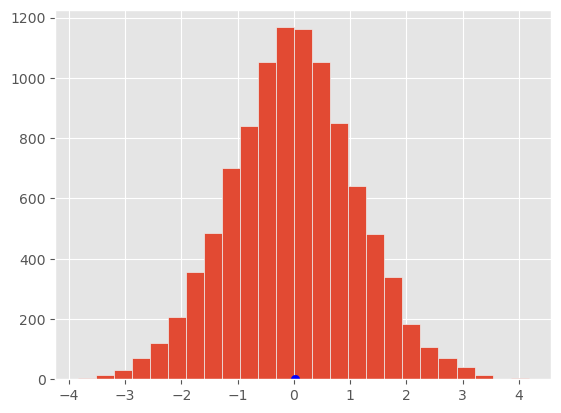

In [53]:
plt.hist(sims, bins = 25)
plt.scatter(test_stat, 0, color='blue')

In [56]:
p_value = np.count_nonzero(sims >= test_stat)/len(sims)

In [57]:
p_value

0.4928

In [58]:
# p_value is 0.4928, or 49.28%; this is greater than 5%, so the null hypothesis is accepted.
# There is NO correlation between the Max temperature and the groundhog's accuracy.

## Conclusion
Thus concludes the Exercises 05. I admit, in my unceasing quest for adequacy, I may have overdone the amount of work you have to do here. If that's the case, feel free to complain here about what parts were unfairly designed or excessive. Your advice will help in creating future versions for future semesters!

Unfortunately, no secret code is hidden in these Exercises. This may change in future versions, however.